<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_error_correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STATE: ERROR_CORRECTION_LOCKED
input sequence:     10110101
encoded sequence:   111000111111000111000111
raw decoded copies: 101010110101010101010101
corrected sequence: 10110101
raw copy accuracy:  0.667
corrected accuracy: 1.0


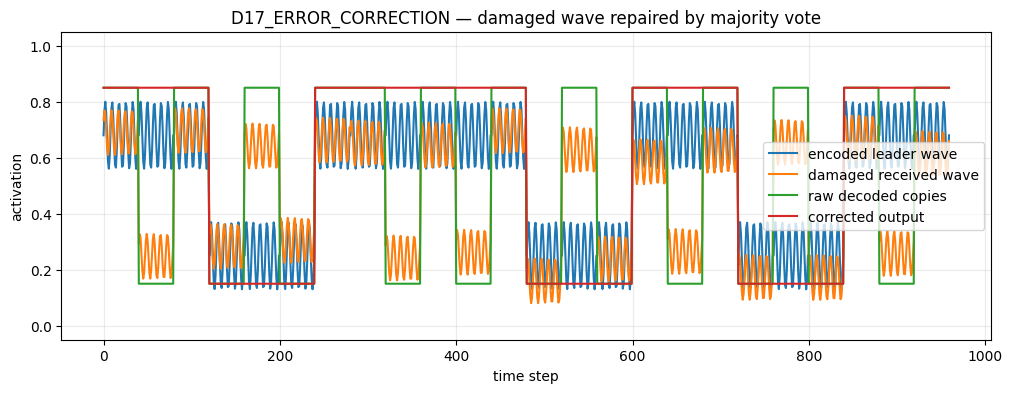

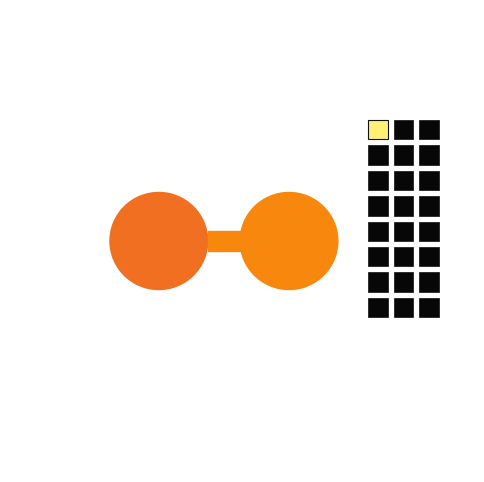

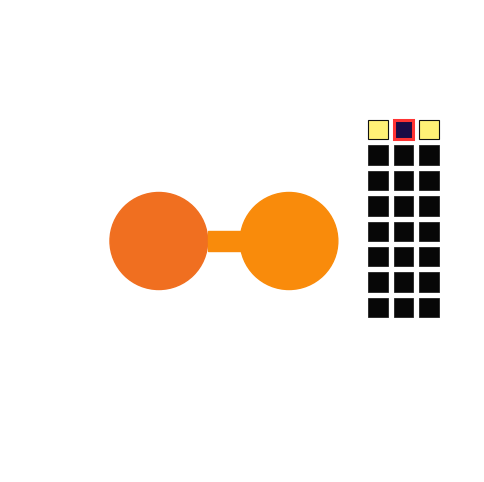

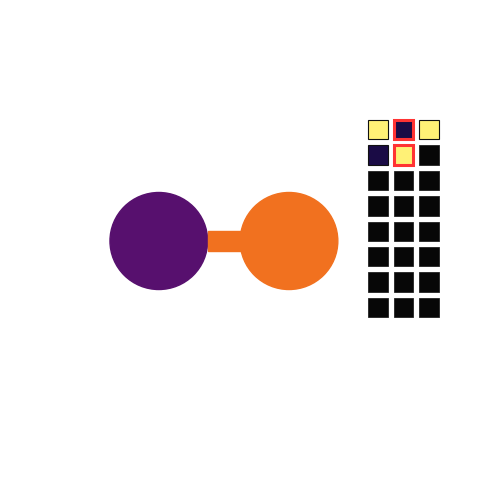

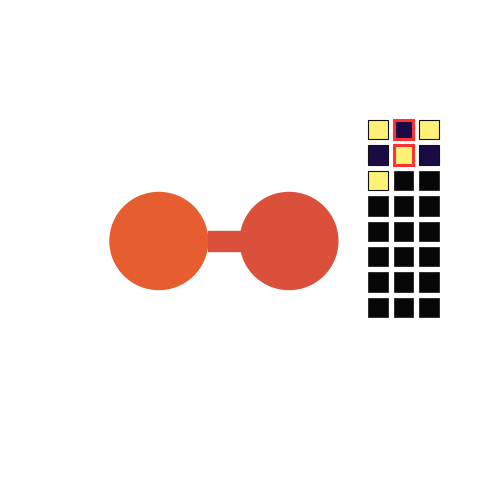

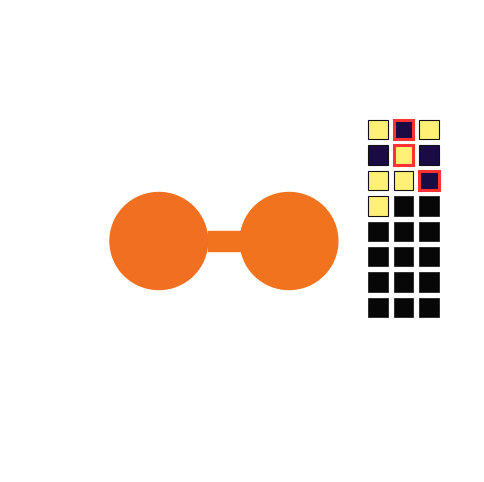

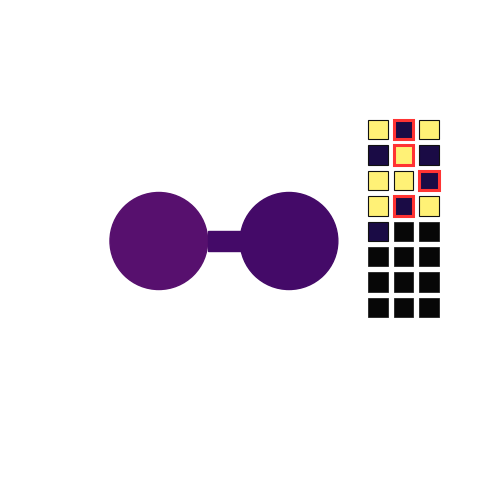

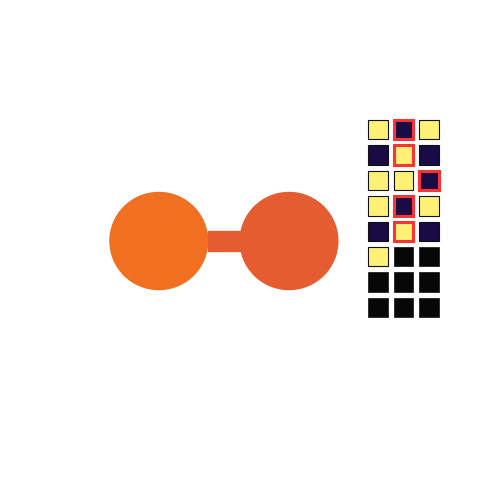

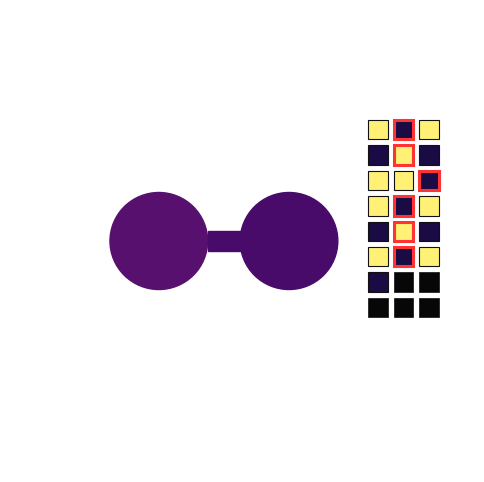

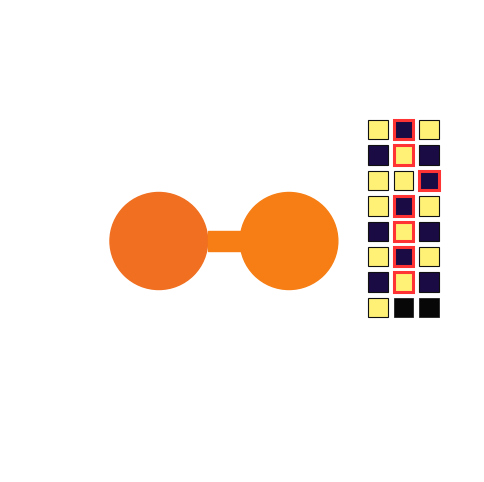

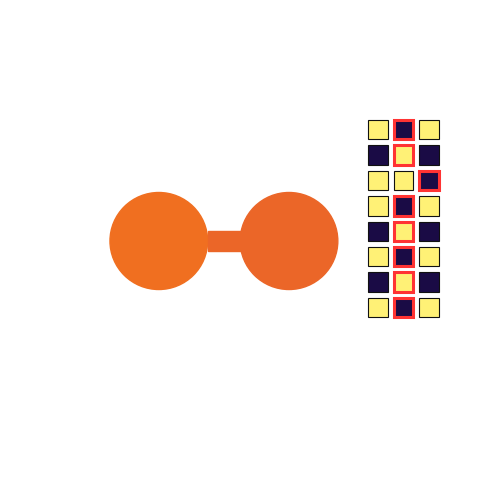

Copy-level damage table:


,STATE,COPY_INDEX,SOURCE_BIT_INDEX,ENCODED_BIT,RECEIVED_MEAN,RAW_DECODED_BIT,COPY_DAMAGED
0,D17_ERROR_CORRECTION,0,0,1,0.690,1,0
1,D17_ERROR_CORRECTION,1,0,1,0.248,0,1
2,D17_ERROR_CORRECTION,2,0,1,0.697,1,0
3,D17_ERROR_CORRECTION,3,1,0,0.284,0,0
4,D17_ERROR_CORRECTION,4,1,0,0.642,1,1
5,D17_ERROR_CORRECTION,5,1,0,0.305,0,0
6,D17_ERROR_CORRECTION,6,2,1,0.663,1,0
7,D17_ERROR_CORRECTION,7,2,1,0.652,1,0
8,D17_ERROR_CORRECTION,8,2,1,0.242,0,1
9,D17_ERROR_CORRECTION,9,3,1,0.645,1,0


Majority repair table:


,STATE,BIT_INDEX,INPUT_BIT,RAW_COPIES,VOTE_SUM,CORRECTED_BIT,MATCH
0,D17_ERROR_CORRECTION,0,1,101,2,1,1
1,D17_ERROR_CORRECTION,1,0,010,1,0,1
2,D17_ERROR_CORRECTION,2,1,110,2,1,1
3,D17_ERROR_CORRECTION,3,1,101,2,1,1
4,D17_ERROR_CORRECTION,4,0,010,1,0,1
5,D17_ERROR_CORRECTION,5,1,101,2,1,1
6,D17_ERROR_CORRECTION,6,0,010,1,0,1
7,D17_ERROR_CORRECTION,7,1,101,2,1,1


Summary:


,STATE,RESULT,INPUT_SEQUENCE,ENCODED_SEQUENCE,RAW_DECODED_COPIES,CORRECTED_SEQUENCE,COPIES_PER_BIT,RAW_COPY_ACCURACY,CORRECTED_ACCURACY,THRESHOLD,DAMAGED_COPIES
0,D17_ERROR_CORRECTION,ERROR_CORRECTION_LOCKED,10110101,111000111111000111000111,101010110101010101010101,10110101,3,0.667,1.0,0.45,8


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# ============================================================
# D17_ERROR_CORRECTION
# Field error correction by redundancy + majority vote
#
# Goal:
# input sequence -> redundant wave encoding -> damaged channel
# -> raw decode -> majority repair -> corrected sequence
# ============================================================

np.random.seed(17)

STATE = "D17_ERROR_CORRECTION"

input_sequence = "10110101"
input_bits = np.array([int(b) for b in input_sequence])

copies_per_bit = 3
bit_len = 40
threshold = 0.45

# Redundant encoding: each bit becomes 3 copies
encoded_bits = np.repeat(input_bits, copies_per_bit)
encoded_sequence = "".join(str(x) for x in encoded_bits)

# ------------------------------------------------------------
# Simulated stressed wave channel
# ------------------------------------------------------------

def bit_to_level(bit):
    return 0.68 if bit == 1 else 0.25

received_means = np.array([bit_to_level(b) for b in encoded_bits], dtype=float)

# Natural channel distortion
noise = np.random.normal(0, 0.035, size=len(received_means))
attenuation = np.linspace(0.00, 0.05, len(received_means))
received_means = received_means + noise - attenuation

# Intentional single-copy damage inside each triplet
# This simulates a D16-like break region, but not enough to destroy majority.
damaged_copy_indices = [1, 4, 8, 10, 13, 16, 19, 22]

for idx in damaged_copy_indices:
    if encoded_bits[idx] == 1:
        received_means[idx] = 0.26 + np.random.normal(0, 0.015)  # force false 0
    else:
        received_means[idx] = 0.64 + np.random.normal(0, 0.015)  # force false 1

received_means = np.clip(received_means, 0, 1)

raw_decoded_bits = (received_means >= threshold).astype(int)
raw_decoded_sequence = "".join(str(x) for x in raw_decoded_bits)

# ------------------------------------------------------------
# Majority error correction
# ------------------------------------------------------------

corrected_bits = []
majority_rows = []

for i in range(len(input_bits)):
    start = i * copies_per_bit
    end = start + copies_per_bit

    copies = raw_decoded_bits[start:end]
    vote_sum = int(np.sum(copies))
    corrected = 1 if vote_sum >= 2 else 0

    corrected_bits.append(corrected)

    majority_rows.append({
        "STATE": STATE,
        "BIT_INDEX": i,
        "INPUT_BIT": int(input_bits[i]),
        "RAW_COPIES": "".join(str(x) for x in copies),
        "VOTE_SUM": vote_sum,
        "CORRECTED_BIT": corrected,
        "MATCH": int(corrected == input_bits[i])
    })

corrected_bits = np.array(corrected_bits)
corrected_sequence = "".join(str(x) for x in corrected_bits)

raw_copy_accuracy = float(np.mean(raw_decoded_bits == encoded_bits))
corrected_accuracy = float(np.mean(corrected_bits == input_bits))

result = "ERROR_CORRECTION_LOCKED" if corrected_accuracy == 1.0 else "ERROR_CORRECTION_PARTIAL"

# ------------------------------------------------------------
# Build wave traces for visualization
# ------------------------------------------------------------

total_steps = len(encoded_bits) * bit_len
time = np.arange(total_steps)

leader_wave = np.zeros(total_steps)
damaged_wave = np.zeros(total_steps)
raw_decode_wave = np.zeros(total_steps)
corrected_wave = np.zeros(total_steps)

for j, bit in enumerate(encoded_bits):
    a = j * bit_len
    b = a + bit_len
    local_t = np.linspace(0, 2 * np.pi, bit_len)

    leader_level = bit_to_level(bit)
    channel_level = received_means[j]
    decoded_level = 0.85 if raw_decoded_bits[j] == 1 else 0.15

    leader_wave[a:b] = leader_level + 0.12 * np.sin(5 * local_t)
    damaged_wave[a:b] = channel_level + 0.08 * np.sin(5 * local_t + 0.6)
    raw_decode_wave[a:b] = decoded_level

# Corrected output expanded back to wave format
for i, bit in enumerate(corrected_bits):
    for c in range(copies_per_bit):
        j = i * copies_per_bit + c
        a = j * bit_len
        b = a + bit_len
        corrected_wave[a:b] = 0.85 if bit == 1 else 0.15

# ------------------------------------------------------------
# Visualization helpers
# ------------------------------------------------------------

def draw_square(ax, x, y, value, error=False, alpha=1.0):
    color = "#fff176" if value == 1 else "#1a0b45"
    edge = "#ff3333" if error else "#111111"
    lw = 2.2 if error else 0.8
    ax.add_patch(Rectangle((x, y), 0.42, 0.42, facecolor=color, edgecolor=edge, linewidth=lw, alpha=alpha))

def draw_snapshot(t, title_suffix=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_facecolor("black")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    # Field cells
    phase = damaged_wave[min(t, total_steps - 1)]
    left_level = leader_wave[min(t, total_steps - 1)]
    right_level = damaged_wave[min(t, total_steps - 1)]

    left_color = plt.cm.inferno(left_level)
    right_color = plt.cm.inferno(right_level)

    ax.add_patch(Circle((3.2, 5), 1.05, color=left_color))
    ax.add_patch(Circle((6.0, 5), 1.05, color=right_color))
    ax.add_patch(Rectangle((4.25, 4.78), 0.75, 0.44, color=plt.cm.inferno(phase)))

    # Memory / redundancy grid
    copies_written = min(t // bit_len + 1, len(encoded_bits))

    x0 = 7.7
    y0 = 7.2
    gap = 0.55

    for i in range(len(input_bits)):
        for c in range(copies_per_bit):
            copy_index = i * copies_per_bit + c
            if copy_index < copies_written:
                value = int(raw_decoded_bits[copy_index])
                error = value != int(encoded_bits[copy_index])
                draw_square(ax, x0 + c * gap, y0 - i * gap, value, error=error)
            else:
                ax.add_patch(Rectangle(
                    (x0 + c * gap, y0 - i * gap),
                    0.42,
                    0.42,
                    facecolor="#070707",
                    edgecolor="#222222",
                    linewidth=0.6
                ))

    ax.text(0.2, 9.5, f"D17 snapshot t={t} {title_suffix}", color="white", fontsize=11)
    ax.text(0.2, 0.5, "red outline = damaged copy", color="white", fontsize=9)

    plt.show()

# ------------------------------------------------------------
# Main plots
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"input sequence:     {input_sequence}")
print(f"encoded sequence:   {encoded_sequence}")
print(f"raw decoded copies: {raw_decoded_sequence}")
print(f"corrected sequence: {corrected_sequence}")
print(f"raw copy accuracy:  {round(raw_copy_accuracy, 3)}")
print(f"corrected accuracy: {round(corrected_accuracy, 3)}")

plt.figure(figsize=(12, 4))
plt.plot(leader_wave, label="encoded leader wave")
plt.plot(damaged_wave, label="damaged received wave")
plt.plot(raw_decode_wave, label="raw decoded copies")
plt.plot(corrected_wave, label="corrected output")
plt.title("D17_ERROR_CORRECTION — damaged wave repaired by majority vote")
plt.xlabel("time step")
plt.ylabel("activation")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

for snap in [0, 80, 160, 260, 360, 480, 600, 720, 840, total_steps - 1]:
    draw_snapshot(snap)

# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

df_copies = pd.DataFrame({
    "STATE": STATE,
    "COPY_INDEX": np.arange(len(encoded_bits)),
    "SOURCE_BIT_INDEX": np.arange(len(encoded_bits)) // copies_per_bit,
    "ENCODED_BIT": encoded_bits,
    "RECEIVED_MEAN": np.round(received_means, 3),
    "RAW_DECODED_BIT": raw_decoded_bits,
    "COPY_DAMAGED": (raw_decoded_bits != encoded_bits).astype(int)
})

df_majority = pd.DataFrame(majority_rows)

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "INPUT_SEQUENCE": input_sequence,
    "ENCODED_SEQUENCE": encoded_sequence,
    "RAW_DECODED_COPIES": raw_decoded_sequence,
    "CORRECTED_SEQUENCE": corrected_sequence,
    "COPIES_PER_BIT": copies_per_bit,
    "RAW_COPY_ACCURACY": round(raw_copy_accuracy, 3),
    "CORRECTED_ACCURACY": round(corrected_accuracy, 3),
    "THRESHOLD": threshold,
    "DAMAGED_COPIES": len(damaged_copy_indices)
}])

print("Copy-level damage table:")
display(df_copies)

print("Majority repair table:")
display(df_majority)

print("Summary:")
display(df_summary)